In [2]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from modules import PhysicsInformedSustainabilityModel
from modules import NigerianManufacturingContext
import pickle
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [3]:
# Load dataset (AI4I)
try:
    # Try loading local file first
    data = pd.read_csv('../data/ai4i2020_local.csv')
except:
    # Download if not available locally
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
    data = pd.read_csv(url)
    # Save locally
    import os
    os.makedirs('../data', exist_ok=True)
    data.to_csv('../data/ai4i2020_local.csv', index=False)

In [4]:
# Check for missing values
print("Check for Missing Values")
print(data.isnull().sum())

# check data summary
print("\n\nSummary Statistics")
display(data.describe().T)

Check for Missing Values
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


Summary Statistics


,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


In [5]:
# Adding comprehensive sustainability features
physics_model = PhysicsInformedSustainabilityModel()
nigeria_context = NigerianManufacturingContext()
df = data.copy()

# 1. Add physics-based energy consumption
df['energy_consumption_kwh'] = df.apply(
    physics_model.calculate_energy_consumption, axis=1
)

# 2. Add power condition simulation
n_samples = len(df)
power_states, power_factors, diesel_usage = nigeria_context.simulate_power_conditions(n_samples)

state_mapping = {
    'stable_grid': 0,
    'brownout': 1,
    'blackout': 2,
    'diesel_gen': 3,
    'voltage_spike': 4
}
power_states_numeric = np.array([state_mapping[s] for s in power_states])

df['power_state'] = power_states
df['power_state_numeric'] = power_states_numeric
df['power_quality_factor'] = power_factors
df['on_diesel'] = diesel_usage

# 3. Adjust energy for power conditions
df['actual_energy_kwh'] = df['energy_consumption_kwh'] * (1 + (1 - df['power_quality_factor']) * 0.2)

# 4. Calculate emissions (Nigerian specific)
# Grid emission factor for Nigeria: 0.47 kg CO2/kWh (IEA data)
# Diesel generator: 0.804 kg CO2/kWh
df['grid_emissions_kg_co2'] = df['actual_energy_kwh'] * 0.47 * (1 - df['on_diesel'])
df['diesel_emissions_kg_co2'] = df['actual_energy_kwh'] * 0.804 * df['on_diesel']
df['total_emissions_kg_co2'] = df['grid_emissions_kg_co2'] + df['diesel_emissions_kg_co2']

# 5. Calculate operational costs in USD and convert to Naira
df['energy_cost_usd'] = (
    df['actual_energy_kwh'] * nigeria_context.grid_cost_per_kwh * (1 - df['on_diesel']) +
    df['actual_energy_kwh'] * nigeria_context.diesel_cost_per_kwh * df['on_diesel']
)
df['energy_cost_ngn'] = df['energy_cost_usd'] * nigeria_context.usd_to_ngn

# 6. Add maintenance urgency score (0-100)
# Based on multiple factors
df['maintenance_urgency'] = (
    df['Tool wear [min]'] / df['Tool wear [min]'].max() * 40 +  # Wear contribution
    df['Machine failure'] * 30 +  # Failure flag contribution
    (df['actual_energy_kwh'] / df['actual_energy_kwh'].quantile(0.9)) * 20 +  # Energy anomaly
    df['on_diesel'] * 10  # Diesel usage adds urgency
).clip(0, 100)

# 7. Add degradation rate (accounting for tropical conditions)
base_degradation_rate = df['Tool wear [min]'].diff().fillna(0).clip(lower=0) / 60  # per hour
df['tropical_degradation_rate'] = nigeria_context.calculate_tropical_wear_acceleration(
    base_degradation_rate
)

# Set energy and emissions to zero during blackouts
blackout_mask = df['power_state'] == 'blackout'
df.loc[blackout_mask, 'actual_energy_kwh'] = 0
df.loc[blackout_mask, 'grid_emissions_kg_co2'] = 0
df.loc[blackout_mask, 'diesel_emissions_kg_co2'] = 0
df.loc[blackout_mask, 'total_emissions_kg_co2'] = 0
df.loc[blackout_mask, 'energy_cost_usd'] = 0
df.loc[blackout_mask, 'energy_cost_ngn'] = 0

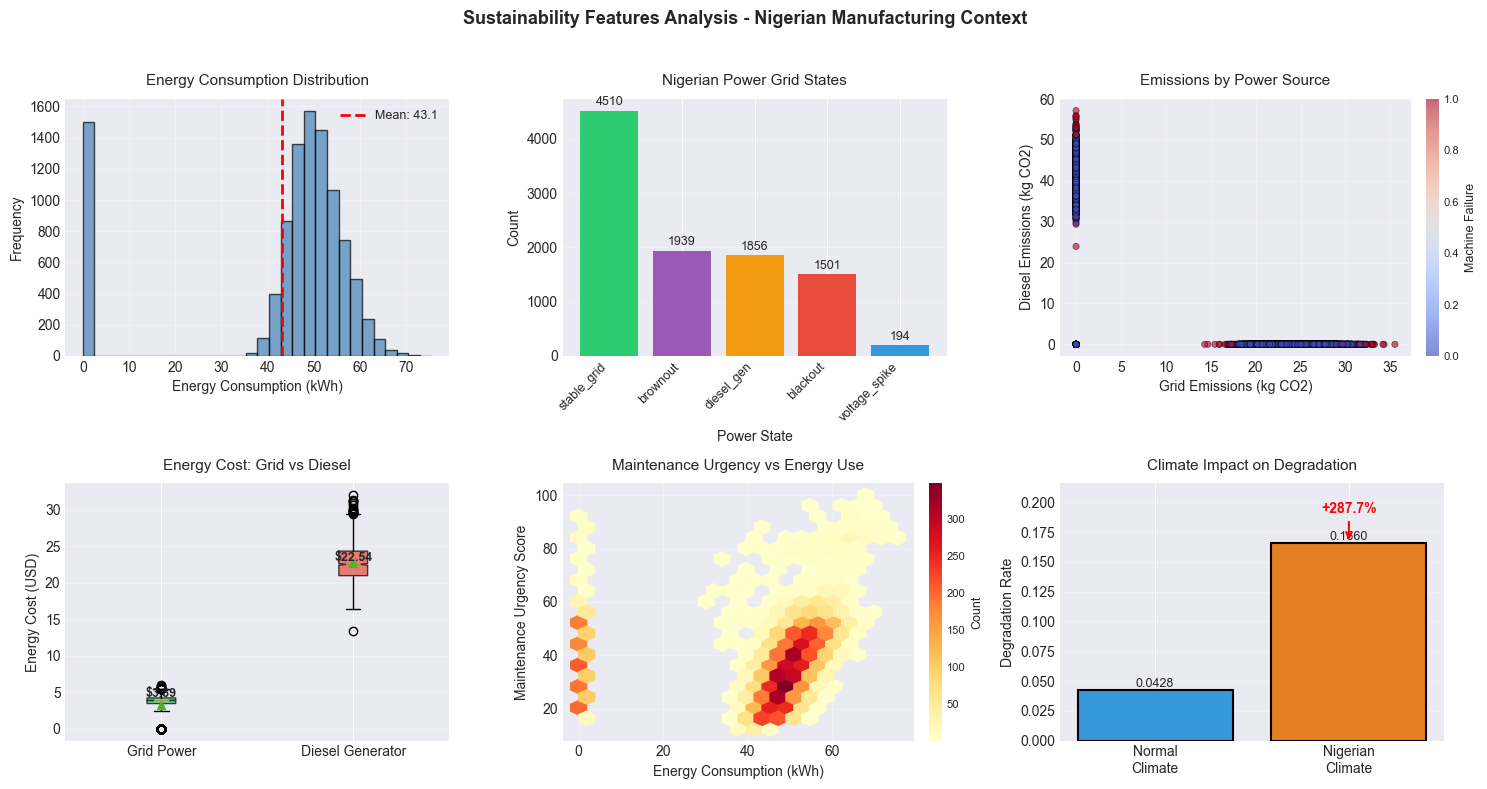

In [6]:

fig, axes = plt.subplots(2, 3, figsize=(15, 8)) 

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.3, wspace=0.25) 

# 1. Energy consumption distribution
axes[0, 0].hist(df['actual_energy_kwh'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('Energy Consumption (kWh)', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].set_title('Energy Consumption Distribution', fontsize=11, pad=10)
axes[0, 0].axvline(df['actual_energy_kwh'].mean(), color='red', linestyle='--', 
                    label=f'Mean: {df["actual_energy_kwh"].mean():.1f}', linewidth=2)
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

# 2. Power state distribution
power_state_counts = df['power_state'].value_counts()
colors_bar = ['#2ecc71' if x=='stable_grid' else '#e74c3c' if x=='blackout' else 
              '#f39c12' if x=='diesel_gen' else '#9b59b6' if x=='brownout' else '#3498db' 
              for x in power_state_counts.index]
bars = axes[0, 1].bar(range(len(power_state_counts)), power_state_counts.values, color=colors_bar)
axes[0, 1].set_xlabel('Power State', fontsize=10)
axes[0, 1].set_ylabel('Count', fontsize=10)
axes[0, 1].set_title('Nigerian Power Grid States', fontsize=11, pad=10)
axes[0, 1].set_xticks(range(len(power_state_counts)))
axes[0, 1].set_xticklabels(power_state_counts.index, rotation=45, ha='right', fontsize=9)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for i, (bar, count) in enumerate(zip(bars, power_state_counts.values)):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                    str(count), ha='center', va='bottom', fontsize=9)

# 3. Emissions by power source
scatter = axes[0, 2].scatter(df['grid_emissions_kg_co2'], df['diesel_emissions_kg_co2'], 
                             alpha=0.6, c=df['Machine failure'], cmap='coolwarm',
                             s=20, edgecolors='black', linewidth=0.5)
axes[0, 2].set_xlabel('Grid Emissions (kg CO2)', fontsize=10)
axes[0, 2].set_ylabel('Diesel Emissions (kg CO2)', fontsize=10)
axes[0, 2].set_title('Emissions by Power Source', fontsize=11, pad=10)
axes[0, 2].grid(True, alpha=0.3)

# Add colorbar with proper spacing
cbar = plt.colorbar(scatter, ax=axes[0, 2], fraction=0.046, pad=0.04)
cbar.set_label('Machine Failure', fontsize=9)
cbar.ax.tick_params(labelsize=8)

# 4. Energy cost analysis
grid_costs = df[df['on_diesel']==0]['energy_cost_usd'].dropna()
diesel_costs = df[df['on_diesel']==1]['energy_cost_usd'].dropna()

bp = axes[1, 0].boxplot([grid_costs, diesel_costs],
                         labels=['Grid Power', 'Diesel Generator'],
                         patch_artist=True, notch=True, showmeans=True)

# Color the boxes
for patch, color in zip(bp['boxes'], ['#2ecc71', '#e74c3c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1, 0].set_ylabel('Energy Cost (USD)', fontsize=10)
axes[1, 0].set_title('Energy Cost: Grid vs Diesel', fontsize=11, pad=10)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Add median values as text
medians = [grid_costs.median(), diesel_costs.median()]
for i, (median, box) in enumerate(zip(medians, bp['boxes'])):
    x = box.get_path().vertices[0][0] + (box.get_path().vertices[2][0] - box.get_path().vertices[0][0]) / 2
    axes[1, 0].text(x, median, f'${median:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 5. Maintenance urgency vs energy
hexbin = axes[1, 1].hexbin(df['actual_energy_kwh'], df['maintenance_urgency'],
                           gridsize=20, cmap='YlOrRd', mincnt=1)
axes[1, 1].set_xlabel('Energy Consumption (kWh)', fontsize=10)
axes[1, 1].set_ylabel('Maintenance Urgency Score', fontsize=10)
axes[1, 1].set_title('Maintenance Urgency vs Energy Use', fontsize=11, pad=10)
axes[1, 1].grid(True, alpha=0.3)

# Add colorbar
cb = plt.colorbar(hexbin, ax=axes[1, 1], fraction=0.046, pad=0.04)
cb.set_label('Count', fontsize=9)
cb.ax.tick_params(labelsize=8)

# 6. Degradation rate comparison
normal_deg = base_degradation_rate.mean()
tropical_deg = df['tropical_degradation_rate'].mean()

bars = axes[1, 2].bar(['Normal\nClimate', 'Nigerian\nClimate'], 
                      [normal_deg, tropical_deg],
                      color=['#3498db', '#e67e22'], 
                      edgecolor='black', linewidth=1.5)

axes[1, 2].set_ylabel('Degradation Rate', fontsize=10)
axes[1, 2].set_title('Climate Impact on Degradation', fontsize=11, pad=10)
axes[1, 2].set_ylim(0, max(tropical_deg * 1.3, normal_deg * 1.3))
axes[1, 2].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[1, 2].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.4f}', ha='center', va='bottom', fontsize=9)

# Add percentage increase text with arrow
increase = (tropical_deg - normal_deg) / normal_deg * 100
axes[1, 2].annotate(f'+{increase:.1f}%', 
                    xy=(1, tropical_deg), 
                    xytext=(1, tropical_deg * 1.15),
                    ha='center', fontsize=10, fontweight='bold', color='red',
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

# Add a main title for the entire figure
fig.suptitle('Sustainability Features Analysis - Nigerian Manufacturing Context', 
             fontsize=13, fontweight='bold', y=0.98)

# Adjust layout to prevent label cutoff
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for suptitle

# Save the figure
plt.savefig('../results/sustainability_features_eda.png', dpi=100, bbox_inches='tight')
plt.show()


# Prepare Multi-Task Learning Targets

In [ ]:
# Define feature columns (inputs)
feature_cols = [
    'Air temperature [K]', 
    'Process temperature [K]',
    'Rotational speed [rpm]', 
    'Torque [Nm]', 
    'Tool wear [min]',
    'power_quality_factor',  # power condition
    'tropical_degradation_rate'  # climate effect
]

# Encode categorical Type column
type_mapping = {'L': 0, 'M': 1, 'H': 2}
df['Type_encoded'] = df['Type'].map(type_mapping)
feature_cols.append('Type_encoded')

# Define target columns (outputs)
target_cols = {
    'failure': 'Machine failure',  
    'energy': 'actual_energy_kwh',  
    'emissions': 'total_emissions_kg_co2',  
    'urgency': 'maintenance_urgency' }

# Extract features
X = df[feature_cols].copy()
power_states = df['power_state_numeric'].values

# Extract all targets
y_multi = {}
for task, col in target_cols.items():
    y_multi[task] = df[col].copy()


# Split data (features, targets)

In [9]:
# First split: separate test set
X_temp, X_test, power_temp, power_test = train_test_split(
    X, power_states, test_size=0.15, random_state=42
)

# Split each target accordingly
y_temp_dict, y_test_dict = {}, {}
for task, y in y_multi.items():
    y_temp_dict[task], y_test_dict[task] = train_test_split(
        y, test_size=0.15, random_state=42
    )

# Second split: separate train and validation
X_train, X_val, power_train, power_val = train_test_split(
    X_temp, power_temp, test_size=0.176, random_state=42
)

y_train_dict, y_val_dict = {}, {}
for task, y_temp in y_temp_dict.items():
    y_train_dict[task], y_val_dict[task] = train_test_split(
        y_temp, test_size=0.176, random_state=42
    )

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Scale continuous targets (energy, emissions, urgency)
target_scalers = {}
for task in ['energy', 'emissions', 'urgency']:
    target_scalers[task] = StandardScaler()
    y_train_dict[task] = target_scalers[task].fit_transform(
        y_train_dict[task].values.reshape(-1, 1)
    ).ravel()
    y_val_dict[task] = target_scalers[task].transform(
        y_val_dict[task].values.reshape(-1, 1)
    ).ravel()
    y_test_dict[task] = target_scalers[task].transform(
        y_test_dict[task].values.reshape(-1, 1)
    ).ravel()


print("📊 Data Split Summary:")
print(f"  Training: {len(X_train)} samples")
print(f"  Validation: {len(X_val)} samples")
print(f"  Test: {len(X_test)} samples")

📊 Data Split Summary:
  Training: 7004 samples
  Validation: 1496 samples
  Test: 1500 samples


In [10]:
# Save Enhanced Dataset

df.to_csv('../data/ai4i2020_enhanced_complete.csv', index=False)

# Save preprocessed data for model training
data_package = {
    'X_train': X_train_scaled,
    'X_val': X_val_scaled,
    'X_test': X_test_scaled,
    'y_train': y_train_dict,
    'y_val': y_val_dict,
    'y_test': y_test_dict,
    'power_states_train': power_train,  
    'power_states_val': power_val,
    'power_states_test': power_test,
    'feature_scaler': scaler,
    'target_scalers': target_scalers,
    'feature_cols': feature_cols,
    'target_cols': target_cols,
    'physics_model': physics_model,
    'nigeria_context': nigeria_context,
}

with open('../data/preprocessed_multitask_data.pkl', 'wb') as f:
    pickle.dump(data_package, f)


In [11]:
df[['actual_energy_kwh', 'total_emissions_kg_co2']].corr()

,actual_energy_kwh,total_emissions_kg_co2
actual_energy_kwh,1.000000,0.843898
total_emissions_kg_co2,0.843898,1.000000


In [12]:
# Check 1: Are power states and on_diesel aligned?
print(df[['power_state', 'on_diesel', 'actual_energy_kwh', 'total_emissions_kg_co2']].head(20))

# Check 2: Emission factors by power source
print("\nEmissions per kWh by power state:")
df['emission_factor'] = df['total_emissions_kg_co2'] / df['actual_energy_kwh']
print(df.groupby('power_state')['emission_factor'].agg(['mean', 'std', 'min', 'max']))

# Check 3: Distribution check
print("\nOn diesel distribution:", df['on_diesel'].value_counts())
print("Power state distribution:", df['power_state'].value_counts())

# Check 4: Are there zeros or NaNs?
print("\nZeros in energy:", (df['actual_energy_kwh'] == 0).sum())
print("Zeros in emissions:", (df['total_emissions_kg_co2'] == 0).sum())
print("NaNs in emissions:", df['total_emissions_kg_co2'].isna().sum())

    power_state  on_diesel  actual_energy_kwh  total_emissions_kg_co2
0   stable_grid          0          47.090927               22.132735
1      brownout          0          49.168821               23.109346
2   stable_grid          0          49.804578               23.408152
3      brownout          0          46.371557               21.794632
4   stable_grid          0          44.142741               20.747088
5    diesel_gen          1          45.795025               36.819200
6   stable_grid          0          47.581953               22.363518
7      blackout          0           0.000000                0.000000
8   stable_grid          0          41.562832               19.534531
9      brownout          0          44.122457               20.737555
10  stable_grid          0          40.020020               18.809410
11  stable_grid          0          47.205512               22.186591
12  stable_grid          0          49.294454               23.168393
13     blackout     